# Activity 2 - PCA

## Principal Component Analysis - Palmer Penguins

### Big Picture

We are taking a dataset with a bunch of columns and slowly cleaning it up so PCA can reduce it into fewer columns.

Basically:

**messy penguin data → clean data → numbers → scale → PCA → fewer columns**

The goal is to keep as much useful information as possible while making the dataset smaller and easier to work with.

## Part 0 - Setup / Where Is Python Standing?

Before loading the dataset, I want to check what folder Python thinks it is working from.

This matters because Python needs the correct path to find the dataset.

**Dumbed down version:**  
"Python, where are you standing right now?"

In [1]:
import os
print(os.getcwd())

d:\Documents_D\RDP_Fall_2026\AIDA2152_MLA2\Week3_Sep14


### What did this tell me?

Python is standing in the main `AIDA2152_MLA2` folder.

My penguin dataset is inside the `Data` folder.

So the path I need is:

`Data/penguins_raw.csv`

# Part 1 - Pre-Flight Check

## What are we doing?

Before changing anything, we need to look at the raw penguin data and see what we are dealing with.

We want to find things like:

- How many rows and columns are there?
- What types of data are in each column?
- Are any values missing?
- What column are we trying to predict?
- Are there useless ID or date columns?
- What does the actual data look like?

### Dumbed down version:

**Look at data first. Break stuff later.**

## Part 1A - Load the Penguin Data

First we load `penguins_raw.csv` into pandas.

`df` will be our dataframe.

**DataFrame = basically a spreadsheet inside Python.**

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../Data/penguins_raw.csv")

# Remove accidental spaces from column names
df.columns = df.columns.str.strip()

df.head()

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,2007-11-11,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,2007-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


### What am I looking at?

This is the first 5 penguins in the raw dataset.

There are a LOT of columns, so this table is mostly just proving:

- the file loaded correctly
- each row = one penguin record
- we have numbers, text, dates, IDs, and missing values
- `NaN` means data is missing

The full table is useful for the activity, but it is way too wide for my brain.

So below I am making a smaller version with only the main columns I care about right now.

### Other Note: Why did the path change?

My notebook is inside the `Week3_Sep14` folder, but the dataset is inside the main `Data` folder.

`..` means:

**"go back one folder"**

So:

`../Data/penguins_raw.csv`

means:

**go back to AIDA2152_MLA2 → open Data → open penguins_raw.csv**

In [3]:
jay_view = df[
    [
        'Species',
        'Island',
        'Culmen Length (mm)',
        'Culmen Depth (mm)',
        'Flipper Length (mm)',
        'Body Mass (g)',
        'Sex'
    ]
]

jay_view.head()

,Species,Island,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,Adelie Penguin (Pygoscelis adeliae),Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie Penguin (Pygoscelis adeliae),Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie Penguin (Pygoscelis adeliae),Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie Penguin (Pygoscelis adeliae),Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin (Pygoscelis adeliae),Torgersen,36.7,19.3,193.0,3450.0,FEMALE


### Jay Brain Check - What am I looking at?

This is the same penguin data, but I only pulled out the columns that are easier to understand right now.

Each row = one penguin.

The main things shown are:

- **Species** = what kind of penguin it is
- **Island** = where it was found
- **Culmen Length** = bill/beak length
- **Culmen Depth** = bill/beak depth
- **Flipper Length** = flipper size
- **Body Mass** = weight
- **Sex** = male or female

`NaN` means that value is missing.

So row 3 is missing several measurements and the penguin's sex.

This smaller table is just for me to understand the data better. The full dataframe still has all 17 original columns.

## Part 1B - Dataset Size

Now I want to see how much data I actually have.

I am checking:

- how many penguin records there are
- how many columns describe each penguin

**Caveman version:**

How many penguins?  
How much stuff do we know about each one?

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 344
Columns: 17


## Part 1C - What Kind of Data Is in Each Column?

Now I want to see what type of information each column contains.

Python mainly sees things like:

- `object` = usually words/text
- `float64` = numbers with decimals
- `int64` = whole numbers

### Caveman version:

**Is this column words or numbers?**

We need to know this because later:

- number columns can go into math/PCA
- text columns will need to be encoded or removed

In [5]:
print("Column type summary:")
print(df.dtypes.value_counts())

print("\nFull breakdown:")
display(df.dtypes.to_frame(name="Data Type"))

Column type summary:
str        10
float64     6
int64       1
Name: count, dtype: int64

Full breakdown:


,Data Type
studyName,str
Sample Number,int64
Species,str
Region,str
Island,str
Stage,str
Individual ID,str
Clutch Completion,str
Date Egg,str
Culmen Length (mm),float64


## Easer Table:

In [6]:
jay_types = pd.DataFrame({
    "Column": df.columns,
    "Python Type": [str(dtype) for dtype in df.dtypes],
    "Jay Translation": [
        "Words / Text" if str(dtype) in ["str", "object"]
        else "Whole Number" if "int" in str(dtype)
        else "Decimal Number" if "float" in str(dtype)
        else "Other"
        for dtype in df.dtypes
    ]
})

jay_types

,Column,Python Type,Jay Translation
0,studyName,str,Words / Text
1,Sample Number,int64,Whole Number
2,Species,str,Words / Text
3,Region,str,Words / Text
4,Island,str,Words / Text
5,Stage,str,Words / Text
6,Individual ID,str,Words / Text
7,Clutch Completion,str,Words / Text
8,Date Egg,str,Words / Text
9,Culmen Length (mm),float64,Decimal Number


### Jay Brain Check - What did this tell me?

The dataset contains three main kinds of data:

- **Words / Text** = things like species, island, sex, and IDs
- **Whole Numbers** = numbers with no decimals
- **Decimal Numbers** = measurements like bill length, flipper length, and body mass

Why do I care?

PCA needs numbers.

So later:

- useful number columns can stay
- useful text categories need to be turned into numbers
- useless text like IDs and dates should be removed

### Dumbed Down:
PCA no understand words.
Keep useful numbers.
Turn useful words into numbers.
Throw useless words away.

## Part 1D - Missing Values

Now I want to find the holes in the dataset.

A missing value usually shows up as `NaN`.

### Caveman version:

**Which columns have blanks, and how many blanks are there?**

We need to know this because PCA cannot work properly with missing values later.

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0]

display(missing.to_frame(name="Missing Count"))

,Missing Count
Culmen Length (mm),2
Culmen Depth (mm),2
Flipper Length (mm),2
Body Mass (g),2
Sex,11
Delta 15 N (o/oo),14
Delta 13 C (o/oo),13
Comments,290


## Jay Simple Version:

In [8]:
jay_missing = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Jay Translation": [
        f"{count} blanks need dealing with"
        for count in missing.values
    ]
})

jay_missing

,Column,Missing Values,Jay Translation
0,Culmen Length (mm),2,2 blanks need dealing with
1,Culmen Depth (mm),2,2 blanks need dealing with
2,Flipper Length (mm),2,2 blanks need dealing with
3,Body Mass (g),2,2 blanks need dealing with
4,Sex,11,11 blanks need dealing with
5,Delta 15 N (o/oo),14,14 blanks need dealing with
6,Delta 13 C (o/oo),13,13 blanks need dealing with
7,Comments,290,290 blanks need dealing with


### Jay Brain Check - What did this tell me?

Only some columns have missing data.

`NaN` = information is missing.

Some columns only have a couple of blanks, while others have a lot.

We are NOT fixing them yet.

Right now we are only finding the problems.

**Dumbed down version:**

Find holes first.  
Fix holes later.

## Part 1E - Target Check

Now I want to find the target column.

The target is the answer we would eventually want to predict.

For this dataset:

**Target = Species**

### Dumbed down version:

We give the model penguin information.

The answer is:

**"What species is this penguin?"**

Important:

`Species` is the answer, so it should NOT be used as an input feature for PCA.

In [9]:
print("Target column: Species")

print("\nSpecies in the dataset:")
print(df['Species'].unique())

print("\nHow many of each species:")
display(df['Species'].value_counts().to_frame(name="Count"))

Target column: Species

Species in the dataset:
<StringArray>
[      'Adelie Penguin (Pygoscelis adeliae)',
         'Gentoo penguin (Pygoscelis papua)',
 'Chinstrap penguin (Pygoscelis antarctica)']
Length: 3, dtype: str

How many of each species:


,Count
Species,
Adelie Penguin (Pygoscelis adeliae),152
Gentoo penguin (Pygoscelis papua),124
Chinstrap penguin (Pygoscelis antarctica),68


### Dumbed Down Version

`Species` is the target.

That just means it is the answer we would eventually want a model to predict.

We give the model information about a penguin, such as:

- bill length
- bill depth
- flipper length
- body mass
- sex
- island

Then the answer we want is:

**"What species is this penguin?"**

There are 3 possible species in this dataset:

- Adelie = 152 penguins
- Gentoo = 124 penguins
- Chinstrap = 68 penguins

Important:

`Species` is the answer, so it must stay separate from the input data used for PCA.

If we gave PCA the species column as an input, we would basically be giving it the answer.

## Part 1F - ID / Date / Useless Text Check

Now I want to find columns that probably should NOT be used as machine learning features.

These are things like:

- unique IDs
- dates
- study names
- row numbers
- comment fields

### Dumbed Down Version

Some columns describe the penguin.

Other columns are just labels or bookkeeping.

PCA does not need stuff like:

- "Penguin ID = N1A1"
- "Sample Number = 1"
- "Date = 2007-11-11"

Those do not describe the penguin in a useful way for PCA.

So for now we are just finding those columns.

In [10]:
id_traps = [
    'Individual ID',
    'Date Egg',
    'studyName',
    'Sample Number',
    'Comments'
]

found_traps = [col for col in id_traps if col in df.columns]

print("ID / Date / Text columns found:")
print(found_traps)

ID / Date / Text columns found:
['Individual ID', 'Date Egg', 'studyName', 'Sample Number', 'Comments']


### What did this tell me?

These columns exist in the dataset, but they are not useful PCA features.

They are mostly IDs, dates, or notes.

We are NOT deleting them yet.

We are just identifying them now so we know what needs to be removed later.

### Dumbed Down Version

Useful penguin info = keep.

Random labels / IDs / dates = probably delete later.

# Part 1 Complete ✅

So far I have:

- loaded the penguin dataset
- checked the size
- checked the data types
- found missing values
- identified the target (`Species`)
- found ID/date/text columns that may need to be removed later

Now I understand what is in the raw dataset before changing it.

# Part 2 - Understanding the Columns

Before changing the data, I need to decide what job each column has.

There are basically 4 types I care about:

- **Target** = the answer we eventually want to predict
- **Numeric** = useful number measurements
- **Categorical** = useful groups/words that will need to become numbers later
- **Identifier** = IDs, dates, row numbers, or notes that should be removed

### Dumbed Down Version

Not every column deserves to go into PCA.

Some columns actually describe the penguin.

Some columns are useful words that can be converted into numbers.

Some columns are just bookkeeping junk.

And `Species` is special because it is the answer, not an input.

### What happens to the main columns?

| Column | What is it? | What do we do? |
|---|---|---|
| Species | Target / answer | Keep separate as `y` |
| Culmen Length | Number | Keep |
| Culmen Depth | Number | Keep |
| Flipper Length | Number | Keep |
| Body Mass | Number | Keep |
| Delta 15 N | Number | Keep |
| Delta 13 C | Number | Keep |
| Region | Category | Encode later |
| Island | Category | Encode later |
| Stage | Category | Encode later |
| Clutch Completion | Category | Encode later |
| Sex | Category | Encode later |
| studyName | Identifier | Drop later |
| Sample Number | Identifier | Drop later |
| Individual ID | Identifier | Drop later |
| Date Egg | Date / identifier | Drop later |
| Comments | Notes / identifier | Drop later |

### Main idea

**Keep useful penguin information.**

**Convert useful words into numbers.**

**Delete IDs/dates/notes.**

**Never put `Species` into PCA because `Species` is the answer.**

# Part 3 - Text Column Diagnostic

Now I am checking the text columns automatically.

The code asks:

**"Does this column repeat the same few categories, or is almost every row different?"**

If the same values repeat a lot, it is probably a useful category.

If almost every value is different, it is probably an ID.

### Dumbed Down Version

Examples:

`Sex` only has values like MALE and FEMALE.

That repeats a lot = useful category.

`Individual ID` has a different ID for almost every penguin.

That does NOT repeat much = probably useless for PCA.

In [11]:
text_cols = [
    col for col in df.columns
    if pd.api.types.is_string_dtype(df[col])
]

total_rows = len(df)

print("TEXT COLUMN DIAGNOSTIC")
print("-" * 70)

for col in text_cols:
    unique_count = df[col].nunique()
    ratio = unique_count / total_rows

    if ratio > 0.5:
        verdict = "DROP? - probably an identifier"
    else:
        verdict = "KEEP? - probably a category"

    print(
        f"{col:25s} | "
        f"unique: {unique_count:3d}/{total_rows} | "
        f"{verdict}"
    )

TEXT COLUMN DIAGNOSTIC
----------------------------------------------------------------------
studyName                 | unique:   3/344 | KEEP? - probably a category
Species                   | unique:   3/344 | KEEP? - probably a category
Region                    | unique:   1/344 | KEEP? - probably a category
Island                    | unique:   3/344 | KEEP? - probably a category
Stage                     | unique:   1/344 | KEEP? - probably a category
Individual ID             | unique: 190/344 | DROP? - probably an identifier
Clutch Completion         | unique:   2/344 | KEEP? - probably a category
Date Egg                  | unique:  50/344 | KEEP? - probably a category
Sex                       | unique:   2/344 | KEEP? - probably a category
Comments                  | unique:  10/344 | KEEP? - probably a category


### Dumbed Down Version

This code is trying to guess which text columns are useful categories and which ones are basically IDs.

The rule it uses is:

- lots of repeated values = probably a useful category
- almost every row is different = probably an ID

Examples:

- `Sex` only has 2 values, so it looks like a useful category.
- `Island` only has 3 values, so it looks like a useful category.
- `Individual ID` has 190 different values, so it looks like an identifier.

The automatic rule is NOT perfect.

It says things like `Date Egg`, `studyName`, and `Comments` might be useful categories, but we already know those are not useful PCA features.

So this check gives us a suggestion, but we still make the final decision ourselves.

# Part 4 - Rename Columns

Some of the current column names are long and annoying to type.

Example:

`Culmen Length (mm)`

becomes:

`bill_length_mm`

### Dumbed Down Version

Same data.

Better names.

This does NOT change the actual penguin information.

It only gives the columns cleaner names so the code is easier to read and harder to mess up.

In [12]:
df = df.rename(columns={
    'Species': 'species',
    'Culmen Length (mm)': 'bill_length_mm',
    'Culmen Depth (mm)': 'bill_depth_mm',
    'Flipper Length (mm)': 'flipper_length_mm',
    'Body Mass (g)': 'body_mass_g',
    'Delta 15 N (o/oo)': 'delta_15_n',
    'Delta 13 C (o/oo)': 'delta_13_c',
    'Individual ID': 'individual_id',
    'Date Egg': 'date_egg',
    'Sample Number': 'sample_number',
    'Clutch Completion': 'clutch_completion',
    'studyName': 'study_name'
})

print("New column names:")

for col in df.columns:
    print(col)

New column names:
study_name
sample_number
species
Region
Island
Stage
individual_id
clutch_completion
date_egg
bill_length_mm
bill_depth_mm
flipper_length_mm
body_mass_g
Sex
delta_15_n
delta_13_c
Comments


In [13]:
pd.DataFrame({
    "Current Column Names": df.columns
})

,Current Column Names
0,study_name
1,sample_number
2,species
3,Region
4,Island
5,Stage
6,individual_id
7,clutch_completion
8,date_egg
9,bill_length_mm


# Part 5 - Remove Useless ID / Date Columns

Now I am removing columns that do not actually help describe the penguin.

These are mostly:

- study names
- row/sample numbers
- unique penguin IDs
- dates
- free-text comments

### Dumbed Down Version

Some columns contain useful penguin information.

Other columns are basically bookkeeping.

PCA does not need things like:

- `"Penguin ID = N1A1"`
- `"Sample Number = 27"`
- `"Date Egg = 2007-11-16"`

Those do not describe the penguin's physical features in a useful way.

So now we actually remove them.

In [14]:
identifiers_to_drop = [
    'study_name',
    'sample_number',
    'individual_id',
    'date_egg',
    'Comments'
]

df_filtered = df.drop(
    columns=identifiers_to_drop,
    errors='raise'
)

print("Raw data shape:", df.shape)
print("Filtered data shape:", df_filtered.shape)

print("\nDropped columns:")
print(identifiers_to_drop)

print("\nColumns we kept:")
print(df_filtered.columns.tolist())

Raw data shape: (344, 17)
Filtered data shape: (344, 12)

Dropped columns:
['study_name', 'sample_number', 'individual_id', 'date_egg', 'Comments']

Columns we kept:
['species', 'Region', 'Island', 'Stage', 'clutch_completion', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'Sex', 'delta_15_n', 'delta_13_c']


In [15]:
pd.DataFrame({
    "Columns Still Being Used": df_filtered.columns
})

,Columns Still Being Used
0,species
1,Region
2,Island
3,Stage
4,clutch_completion
5,bill_length_mm
6,bill_depth_mm
7,flipper_length_mm
8,body_mass_g
9,Sex


### What did this do?

We started with 17 columns.

We deleted 5 columns that were mostly IDs, dates, or notes.

Now we have 12 columns left.

Important:

We did NOT delete any penguins.

We only removed information that would not be useful for PCA.

### Dumbed Down Version

**Before:** 344 penguins × 17 columns

**After:** 344 penguins × 12 useful columns

Same penguins. Less junk.

# Part 6 - Split the Data

Now we divide the penguin data into 3 separate groups.

- **Train** = the data the model learns from
- **Validation** = data we use while deciding which settings work best
- **Test** = data we save until the very end for the final check

For this activity we want:

- 60% Train
- 20% Validation
- 20% Test

### Dumbed Down Version

Think of it like studying for a test:

**Train = study material**

The model is allowed to learn from this.

**Validation = practice test**

We use this to make choices and see what works better.

**Test = final exam**

Do NOT use this to practice or make changes.

We only use it once at the very end.

## Part 6A - Separate X and y

Before splitting the data, I separate the target from the features.

- `X` = information about the penguins
- `y` = the answer (`species`)

### Dumbed Down Version

`X` = clues

`y` = answer

The answer must NOT be mixed into the clues.

In [16]:
TARGET_COLUMN = 'species'

y = df_filtered[TARGET_COLUMN].reset_index(drop=True)
X = df_filtered.drop(columns=[TARGET_COLUMN])

print("Target:", TARGET_COLUMN)
print("y shape:", y.shape)
print("X shape:", X.shape)

Target: species
y shape: (344,)
X shape: (344, 11)


## Part 6B - Make Train, Validation, and Test Sets

Now I split the data into:

- 60% Train
- 20% Validation
- 20% Test

`random_state=42` makes the split repeatable.

`stratify=y` helps keep the same mix of penguin species in each group.

### Dumbed Down Version

We are cutting the dataset into 3 piles.

But we want each pile to still have a fair mix of:

- Adelie
- Gentoo
- Chinstrap

So one pile does not accidentally get almost all of one species.

In [17]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# First split:
# 60% stays in train
# 40% temporarily holds validation + test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y
)

# Split the remaining 40% in half:
# 20% validation, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (206, 11) (206,)
Validation: (69, 11) (69,)
Test: (69, 11) (69,)


In [18]:
split_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Penguins": [len(X_train), len(X_val), len(X_test)],
    "What It Is For": [
        "Model learns here",
        "Make/tune decisions here",
        "Final check only"
    ]
})

split_summary

,Dataset,Penguins,What It Is For
0,Train,206,Model learns here
1,Validation,69,Make/tune decisions here
2,Test,69,Final check only


### Visual Check - Did the Species Stay Balanced?

Because I used `stratify=y`, each split should have about the same mix of penguin species.

This graph lets me check that visually.

If the bars look similar across Train, Validation, and Test, the split stayed balanced.

In [19]:
species_balance = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True)
}) * 100

species_balance.round(1)

,Train,Validation,Test
species,,,
Adelie Penguin (Pygoscelis adeliae),44.2,43.5,44.9
Gentoo penguin (Pygoscelis papua),35.9,36.2,36.2
Chinstrap penguin (Pygoscelis antarctica),19.9,20.3,18.8


### Dumbed Down Version

The percentages are almost the same in Train, Validation, and Test.

For example:

- Adelie stays around 44%
- Gentoo stays around 36%
- Chinstrap stays around 20%

That means the split kept a similar mix of species in all 3 groups.

So `stratify=y` worked.

The groups have different numbers of penguins, but the species proportions stayed balanced.

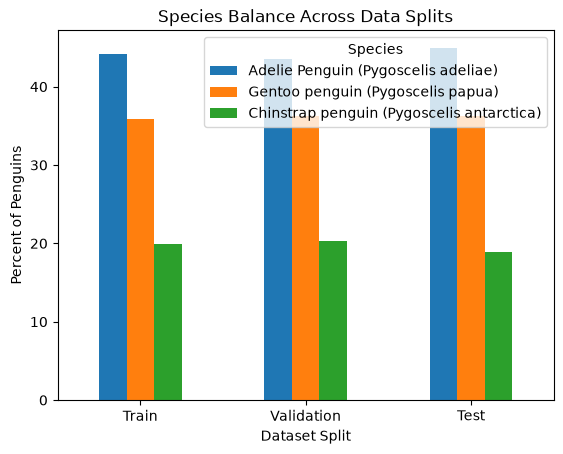

In [20]:
import matplotlib.pyplot as plt

species_balance.T.plot(kind="bar")

plt.title("Species Balance Across Data Splits")
plt.ylabel("Percent of Penguins")
plt.xlabel("Dataset Split")
plt.xticks(rotation=0)
plt.legend(title="Species")
plt.show()

### Dumbed Down Version

The graph shows that the species percentages stayed almost the same in all 3 datasets.

- Adelie stays around 44%
- Gentoo stays around 36%
- Chinstrap stays around 20%

That means the split stayed balanced.

So `stratify=y` worked properly.

**Same species mix, just different group sizes.**

# Part 7 - Fill Missing Values

Now we deal with the `NaN` values we found earlier.

PCA cannot work with missing numbers, so the gaps need to be filled.

For number columns, this activity uses the **median**.

For text columns, missing values become `"Missing"`.

### Important Rule

The fill values must be learned from the **Train set only**.

Then those same Train values are used to fill Validation and Test.

### Dumbed Down Version

Train is allowed to figure out what the normal value is.

Validation and Test are NOT allowed to give us hints.

So:

**Train learns the median.**

**Everyone else copies Train's answer.**

In [21]:
# Find medians using TRAINING data only
train_num_medians = X_train.select_dtypes(include=[np.number]).median()

# Find number and text columns
num_cols = X_train.select_dtypes(include=[np.number]).columns
text_cols = [
    col for col in X_train.columns
    if pd.api.types.is_string_dtype(X_train[col])
]

# Make copies
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

# Fill TRAIN
X_train[num_cols] = X_train[num_cols].fillna(train_num_medians)
X_train[text_cols] = X_train[text_cols].fillna("Missing")

# Fill VALIDATION using TRAIN values
X_val[num_cols] = X_val[num_cols].fillna(train_num_medians)
X_val[text_cols] = X_val[text_cols].fillna("Missing")

# Fill TEST using TRAIN values
X_test[num_cols] = X_test[num_cols].fillna(train_num_medians)
X_test[text_cols] = X_test[text_cols].fillna("Missing")

print("Train missing:", X_train.isnull().sum().sum())
print("Validation missing:", X_val.isnull().sum().sum())
print("Test missing:", X_test.isnull().sum().sum())

Train missing: 0
Validation missing: 0
Test missing: 0


In [22]:
missing_check = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Missing Values Left": [
        X_train.isnull().sum().sum(),
        X_val.isnull().sum().sum(),
        X_test.isnull().sum().sum()
    ],
    "Status": ["Clean", "Clean", "Clean"]
})

missing_check

,Dataset,Missing Values Left,Status
0,Train,0,Clean
1,Validation,0,Clean
2,Test,0,Clean


### Dumbed Down Version

All 3 datasets now have **0 missing values**.

The important part is HOW they were filled:

- Train figured out the median values.
- Validation used Train's medians.
- Test used Train's medians.

Validation and Test did not get to teach us anything.

This avoids data leakage.

# Part 8 - Encode the Text Columns

PCA only works with numbers.

Some of our useful columns are still words, like:

- Region
- Island
- Stage
- Clutch Completion
- Sex

So now we turn those categories into number-style columns using one-hot encoding.

### Dumbed Down Version

PCA does not understand words.

So instead of:

`Island = Torgersen`

we make columns like:

- `Island_Torgersen`
- `Island_Dream`
- `Island_Biscoe`

Then each penguin gets a 1/0 style answer for each category.

Important:

`species` is NOT being encoded here because we already separated it into `y`.

Species = answer.

It does not belong in PCA.

In [23]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

text_cols = [
    col for col in X_train.columns
    if pd.api.types.is_string_dtype(X_train[col])
]

print("Numeric columns:")
print(list(numeric_cols))

print("\nText columns that need encoding:")
print(list(text_cols))

Numeric columns:
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'delta_15_n', 'delta_13_c']

Text columns that need encoding:
['Region', 'Island', 'Stage', 'clutch_completion', 'Sex']


In [24]:
encoding_plan = pd.DataFrame({
    "Column": list(numeric_cols) + list(text_cols),
    "Type": (
        ["Already Numeric"] * len(numeric_cols)
        + ["Needs One-Hot Encoding"] * len(text_cols)
    )
})

encoding_plan

,Column,Type
0,bill_length_mm,Already Numeric
1,bill_depth_mm,Already Numeric
2,flipper_length_mm,Already Numeric
3,body_mass_g,Already Numeric
4,delta_15_n,Already Numeric
5,delta_13_c,Already Numeric
6,Region,Needs One-Hot Encoding
7,Island,Needs One-Hot Encoding
8,Stage,Needs One-Hot Encoding
9,clutch_completion,Needs One-Hot Encoding


## Part 8B - One-Hot Encode the Text

Now I actually convert the useful text categories into numeric columns.

The encoder is fit using TRAIN only.

Validation and Test use the same encoder learned from Train.

### Dumbed Down Version

Train learns:

"These are the categories that exist."

Validation and Test are only allowed to use Train's category rules.

Same rule as before:

**Train learns.**

**Validation and Test copy.**

In [25]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

# Learn categories from TRAIN only
encoder.fit(X_train[text_cols])

def encode_split(data):
    encoded = encoder.transform(data[text_cols])

    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out(text_cols),
        index=data.index
    )

    return pd.concat(
        [data[numeric_cols], encoded_df],
        axis=1
    )

X_train_encoded = encode_split(X_train)
X_val_encoded = encode_split(X_val)
X_test_encoded = encode_split(X_test)

print("Train:", X_train_encoded.shape)
print("Validation:", X_val_encoded.shape)
print("Test:", X_test_encoded.shape)

Train: (206, 16)
Validation: (69, 16)
Test: (69, 16)


In [26]:
encoding_summary = pd.DataFrame({
    "Stage": [
        "Before Encoding",
        "After Encoding"
    ],
    "Number of Feature Columns": [
        X_train.shape[1],
        X_train_encoded.shape[1]
    ]
})

encoding_summary

,Stage,Number of Feature Columns
0,Before Encoding,11
1,After Encoding,16


### Dumbed Down Version

Encoding did NOT make the dataset smaller.

It made the text understandable to the computer.

We went from fewer mixed text/number columns to more all-numeric columns.

That is preparation.

**PCA is the step that will actually shrink the number of columns later.**

# Part 9 - Correlation Matrix

Now I want to see which number features are related to each other.

Correlation tells me whether two measurements tend to move together.

The correlation number goes from:

- **+1** = they strongly increase together
- **0** = not much relationship
- **-1** = one tends to increase while the other decreases

### Dumbed Down Version

This is basically asking:

**"Do any of these penguin measurements tell us almost the same thing?"**

If two columns are highly correlated, they may contain similar information.

That matters because PCA is really good at combining overlapping information.

In [27]:
correlation_matrix = X_train_encoded.corr()

display(correlation_matrix.round(2))

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,delta_15_n,delta_13_c,Region_Anvers,Island_Biscoe,Island_Dream,Island_Torgersen,"Stage_Adult, 1 Egg Stage",clutch_completion_No,clutch_completion_Yes,Sex_FEMALE,Sex_MALE,Sex_Missing
bill_length_mm,1.00,-0.17,0.68,0.61,-0.05,0.17,NaN,0.22,0.03,-0.36,NaN,0.08,-0.08,-0.37,0.41,-0.11
bill_depth_mm,-0.17,1.00,-0.57,-0.49,0.60,0.46,NaN,-0.63,0.49,0.24,NaN,0.11,-0.11,-0.37,0.37,0.01
flipper_length_mm,0.68,-0.57,1.00,0.86,-0.45,-0.34,NaN,0.59,-0.40,-0.31,NaN,-0.11,0.11,-0.22,0.25,-0.08
body_mass_g,0.61,-0.49,0.86,1.00,-0.50,-0.36,NaN,0.61,-0.45,-0.26,NaN,-0.11,0.11,-0.39,0.42,-0.08
delta_15_n,-0.05,0.60,-0.45,-0.50,1.00,0.57,NaN,-0.57,0.62,-0.04,NaN,0.14,-0.14,-0.12,0.14,-0.07
delta_13_c,0.17,0.46,-0.34,-0.36,0.57,1.00,NaN,-0.53,0.60,-0.07,NaN,0.13,-0.13,-0.07,0.06,0.00
Region_Anvers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Island_Biscoe,0.22,-0.63,0.59,0.61,-0.57,-0.53,NaN,1.00,-0.75,-0.40,NaN,-0.14,0.14,0.03,-0.01,-0.06
Island_Dream,0.03,0.49,-0.40,-0.45,0.62,0.60,NaN,-0.75,1.00,-0.30,NaN,0.15,-0.15,-0.04,0.06,-0.07
Island_Torgersen,-0.36,0.24,-0.31,-0.26,-0.04,-0.07,NaN,-0.40,-0.30,1.00,NaN,0.00,-0.00,0.01,-0.07,0.18


In [28]:
numeric_correlation = X_train_encoded[list(numeric_cols)].corr()

numeric_correlation.round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,delta_15_n,delta_13_c
bill_length_mm,1.00,-0.17,0.68,0.61,-0.05,0.17
bill_depth_mm,-0.17,1.00,-0.57,-0.49,0.60,0.46
flipper_length_mm,0.68,-0.57,1.00,0.86,-0.45,-0.34
body_mass_g,0.61,-0.49,0.86,1.00,-0.50,-0.36
delta_15_n,-0.05,0.60,-0.45,-0.50,1.00,0.57
delta_13_c,0.17,0.46,-0.34,-0.36,0.57,1.00


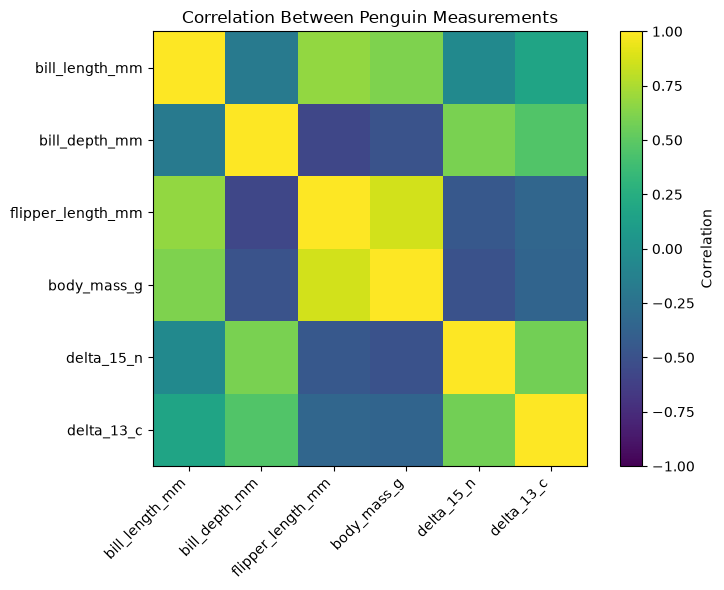

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(
    numeric_correlation,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(numeric_correlation.columns)))
ax.set_yticks(range(len(numeric_correlation.columns)))

ax.set_xticklabels(
    numeric_correlation.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(numeric_correlation.columns)

plt.colorbar(image, label="Correlation")

plt.title("Correlation Between Penguin Measurements")
plt.tight_layout()
plt.show()

### Dumbed Down Version - How to Read Correlation

Correlation tells me how strongly two measurements are related.

The number can go from **-1 to +1**:

- **Close to +1** = both usually increase together
- **Close to -1** = when one increases, the other usually decreases
- **Close to 0** = not much relationship

I mostly care about numbers that are farther away from 0.

### What I See in My Data

The strongest relationship is:

**Flipper Length ↔ Body Mass = 0.86**

This is a strong positive correlation.

That means penguins with longer flippers also tend to weigh more.

Other noticeable relationships:

- Bill Length ↔ Flipper Length = **0.68**
- Bill Length ↔ Body Mass = **0.61**
- Bill Depth ↔ Delta 15 N = **0.60**
- Delta 15 N ↔ Delta 13 C = **0.57**

### Super Simple Version

Some penguin measurements are telling us similar things.

The biggest example is:

**longer flippers usually = heavier penguin**

This overlapping information is one reason PCA can be useful.

In [30]:
pairs = []

for i in range(len(numeric_correlation.columns)):
    for j in range(i + 1, len(numeric_correlation.columns)):
        pairs.append({
            "Feature 1": numeric_correlation.columns[i],
            "Feature 2": numeric_correlation.columns[j],
            "Correlation": numeric_correlation.iloc[i, j]
        })

strongest_correlations = pd.DataFrame(pairs)

strongest_correlations["Strength"] = (
    strongest_correlations["Correlation"].abs()
)

strongest_correlations = strongest_correlations.sort_values(
    "Strength",
    ascending=False
)

strongest_correlations[
    ["Feature 1", "Feature 2", "Correlation"]
].head(5).round(2)

,Feature 1,Feature 2,Correlation
9,flipper_length_mm,body_mass_g,0.86
1,bill_length_mm,flipper_length_mm,0.68
2,bill_length_mm,body_mass_g,0.61
7,bill_depth_mm,delta_15_n,0.60
14,delta_15_n,delta_13_c,0.57


### How to Read the Heatmap

The heatmap is the same correlation information as the table, but shown with colour.

The colour bar on the right goes from **-1 to +1**.

I can use it to quickly spot stronger relationships instead of reading every number in the big table.

The diagonal is always `1.00` because each measurement is perfectly correlated with itself.

The important thing is looking **away from the diagonal** for stronger relationships between different measurements.

### Why I Made This Smaller Table

The full correlation matrix is huge and hard to read.

This table pulls out the strongest relationships between the original numeric penguin measurements.

The strongest pair is:

**flipper_length_mm + body_mass_g = 0.86**

So these two features contain a lot of related information.

PCA can later combine patterns like this into fewer principal components instead of keeping every original feature separately.

### Why Are There Some `NaN` Values in the Big Correlation Table?

These `NaN` values do NOT mean my missing data came back.

Some encoded columns contain the same value for every penguin.

If a column never changes, there is no variation to compare against another column.

Because of that, correlation cannot be calculated and pandas shows `NaN`.

So:

**Missing-data NaN = information was missing**

**Correlation-table NaN = correlation cannot be calculated for a constant column**

# Part 10 - Standardization

Now I need to put all of the features onto a similar scale before using PCA.

Some features have really big numbers:

- Body mass = thousands of grams

Other features have much smaller numbers:

- Bill length = around 30-60 mm

If I leave them like that, PCA could think body mass is more important just because the numbers are bigger.

### Dumbed Down Version

Right now the features are not playing fair.

`body_mass_g = 4000`

while:

`bill_length_mm = 40`

That does NOT mean body mass is 100 times more important.

Standardization puts the features onto a fairer scale so PCA can compare them properly.

After scaling:

- average should be around **0**
- standard deviation should be around **1**

Important:

The scaler learns from **Train only**.

Validation and Test use Train's scaling rules.

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Learn scaling rules from TRAIN only
X_train_scaled = scaler.fit_transform(X_train_encoded)

# Use TRAIN'S rules on Validation and Test
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Train shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

print("\nTrain mean:", X_train_scaled.mean())
print("Train standard deviation:", X_train_scaled.std())

print("\nValidation mean:", X_val_scaled.mean())
print("Test mean:", X_test_scaled.mean())

Train shape: (206, 16)
Validation shape: (69, 16)
Test shape: (69, 16)

Train mean: -2.6596847701578385e-16
Train standard deviation: 0.9354143466934853

Validation mean: -0.011674116547963902
Test mean: -0.026583008847501796


In [32]:
scaling_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Rows": [
        X_train_scaled.shape[0],
        X_val_scaled.shape[0],
        X_test_scaled.shape[0]
    ],
    "Features": [
        X_train_scaled.shape[1],
        X_val_scaled.shape[1],
        X_test_scaled.shape[1]
    ],
    "Overall Mean": [
        X_train_scaled.mean(),
        X_val_scaled.mean(),
        X_test_scaled.mean()
    ],
    "Overall Std": [
        X_train_scaled.std(),
        X_val_scaled.std(),
        X_test_scaled.std()
    ]
})

scaling_summary.round(3)

,Dataset,Rows,Features,Overall Mean,Overall Std
0,Train,206,16,-0.000,0.935
1,Validation,69,16,-0.012,0.883
2,Test,69,16,-0.027,0.986


### How do I read this?

The number of rows and columns did not change.

We still have:

- 206 Train penguins
- 69 Validation penguins
- 69 Test penguins
- 16 features

What changed is the scale of the numbers.

Train should have an overall mean close to **0** and standard deviation close to **1**.

Validation and Test will NOT be exactly 0 and 1 because they were scaled using Train's rules instead of learning their own rules.

That is correct.

### Dumbed Down Version

Before:

One feature might say `4000` while another says `40`.

After:

Everything is put onto a more comparable scale.

**Same information. Fairer numbers.**

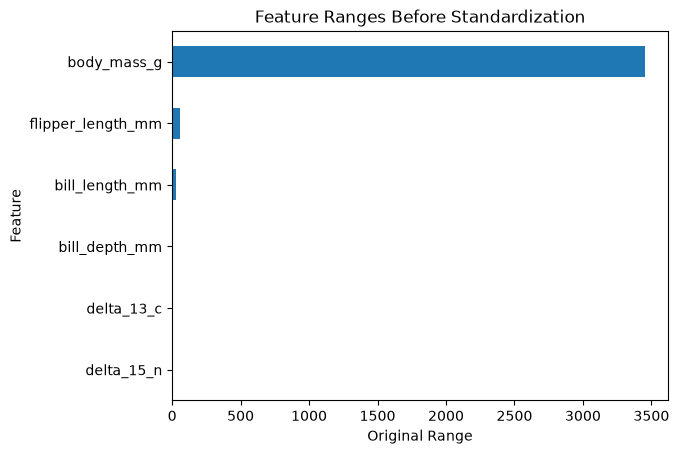

In [33]:
raw_ranges = (
    X_train_encoded[list(numeric_cols)].max()
    - X_train_encoded[list(numeric_cols)].min()
)

raw_ranges.sort_values().plot(kind="barh")

plt.title("Feature Ranges Before Standardization")
plt.xlabel("Original Range")
plt.ylabel("Feature")
plt.show()

### What does this graph show?

Before scaling, some features have MUCH larger numeric ranges than others.

Body mass especially uses much bigger numbers than bill measurements.

This is why standardization is needed before PCA.

The goal is not to erase the differences between penguins.

The goal is to stop the units themselves from controlling PCA.

### Dumbed Down Version

Before standardization, the features were using completely different number sizes.

For example:

- body mass uses numbers in the thousands
- flipper length uses numbers in the hundreds
- bill measurements use numbers around 30-60

The graph makes this really obvious because `body_mass_g` completely dwarfs everything else.

If we gave this directly to PCA, body mass could look more important just because its numbers are bigger.

After standardization, the features are put onto a more comparable scale.

The Train mean is basically **0**, which is what we wanted.

Validation and Test are not exactly 0 because they were scaled using the rules learned from Train.

**Same penguin information. Fairer number scale.**

# Part 11 - Apply PCA

Now we finally use PCA.

PCA takes the 16 features we currently have and creates new combined features called:

**Principal Components**

They are named:

- PC1
- PC2
- PC3
- PC4
- etc.

Each principal component tries to capture some of the important variation in the original data.

### Dumbed Down Version

Right now we have 16 separate pieces of penguin information.

PCA tries to squish that information into fewer "combo columns."

Think of it like:

**16 original columns → fewer summary columns**

The goal is to shrink the data without throwing away too much useful information.

In [34]:
from sklearn.decomposition import PCA

pca_explorer = PCA(random_state=42)

# Learn PCA using TRAIN only
X_train_pca_all = pca_explorer.fit_transform(X_train_scaled)

# Validation and Test use TRAIN'S PCA
X_val_pca_all = pca_explorer.transform(X_val_scaled)
X_test_pca_all = pca_explorer.transform(X_test_scaled)

explained_variance_ratio = pca_explorer.explained_variance_ratio_
eigenvalues = pca_explorer.explained_variance_
loadings = pca_explorer.components_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Input features:", X_train_scaled.shape[1])
print("PCA components created:", pca_explorer.n_components_)

print("\nTrain:", X_train_pca_all.shape)
print("Validation:", X_val_pca_all.shape)
print("Test:", X_test_pca_all.shape)

Input features: 16
PCA components created: 16

Train: (206, 16)
Validation: (69, 16)
Test: (69, 16)


In [35]:
pca_summary = pd.DataFrame({
    "Component": [
        f"PC{i+1}"
        for i in range(len(explained_variance_ratio))
    ],

    "Variance Kept (%)":
        explained_variance_ratio * 100,

    "Total Variance Kept (%)":
        cumulative_variance * 100,

    "Eigenvalue":
        eigenvalues,

    "Eigenvalue > 1?": [
        "YES" if eig > 1 else "NO"
        for eig in eigenvalues
    ]
})

pca_summary.round(2)

,Component,Variance Kept (%),Total Variance Kept (%),Eigenvalue,Eigenvalue > 1?
0,PC1,32.31,32.31,4.55,YES
1,PC2,20.38,52.69,2.87,YES
2,PC3,13.72,66.41,1.93,YES
3,PC4,11.37,77.77,1.60,YES
4,PC5,7.18,84.95,1.01,YES
5,PC6,5.34,90.29,0.75,NO
6,PC7,3.47,93.76,0.49,NO
7,PC8,2.64,96.40,0.37,NO
8,PC9,1.75,98.15,0.25,NO
9,PC10,1.15,99.29,0.16,NO


### How to Read This Table

Each row is one new PCA component.

**Variance Kept (%)**
= how much information that ONE component captures.

**Total Variance Kept (%)**
= how much information we have captured so far after adding that component.

Example:

If:

- PC1 keeps 32%
- PC2 keeps 20%

then PC1 + PC2 together keep about **52%** of the original information.

**Eigenvalue**
= another way of measuring how much useful variation a component captures.

A common rule says:

**Eigenvalue > 1 = component may be worth keeping.**

### Dumbed Down Version - What Did PCA Find?

PCA created 16 possible principal components because we started with 16 features.

But the components are NOT equally useful.

The first few components hold most of the information:

- **PC1 alone = 32.31%**
- **PC1 + PC2 = 52.69%**
- **First 3 PCs = 66.41%**
- **First 4 PCs = 77.77%**
- **First 5 PCs = 84.95%**
- **First 6 PCs = 90.29%**

So I do NOT need all 16 components to keep most of the information.

For example:

**6 components keep about 90% of the original information.**

That means PCA could shrink:

**16 features → 6 components**

while still keeping about **90%** of the variation in the data.

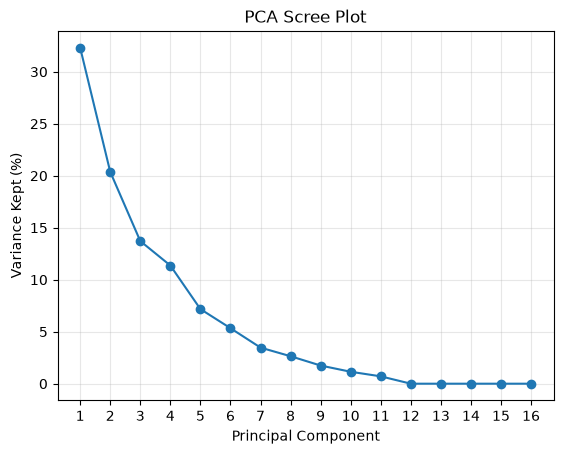

In [36]:
component_numbers = range(1, len(explained_variance_ratio) + 1)

plt.plot(
    component_numbers,
    explained_variance_ratio * 100,
    marker="o"
)

plt.title("PCA Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Variance Kept (%)")
plt.xticks(component_numbers)
plt.grid(alpha=0.3)
plt.show()

### How Do I Read the Scree Plot?

Each dot is one principal component.

The higher the dot, the more information that component adds.

PC1 adds a lot of information.

PC2 still adds quite a bit.

After the first several components, each new component adds less and less.

The line starts flattening out because the later components are not contributing much new information.

### Dumbed Down Version

The first few PCs do most of the work.

The later PCs are basically giving us smaller and smaller scraps of extra information.

### What About PC12-PC16 Showing 0%?

The last several components show almost no variance.

That does NOT mean PCA broke.

Some of the encoded columns were constant or redundant, so they did not contain useful new variation.

PCA basically figured out:

**"There is nothing new left here."**

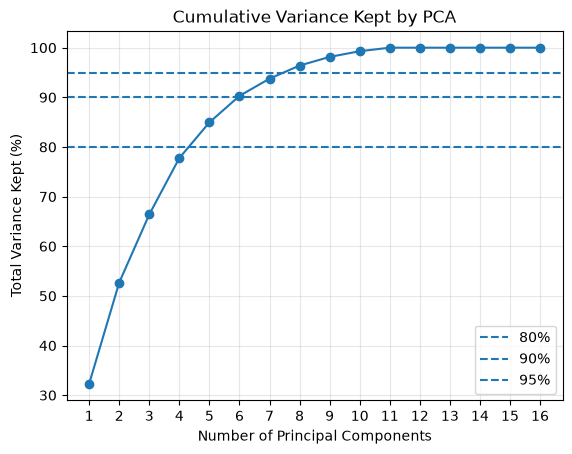

In [37]:
plt.plot(
    component_numbers,
    cumulative_variance * 100,
    marker="o"
)

plt.axhline(80, linestyle="--", label="80%")
plt.axhline(90, linestyle="--", label="90%")
plt.axhline(95, linestyle="--", label="95%")

plt.title("Cumulative Variance Kept by PCA")
plt.xlabel("Number of Principal Components")
plt.ylabel("Total Variance Kept (%)")
plt.xticks(component_numbers)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Dumbed Down Version - Cumulative Variance

This graph asks:

**"If I keep this many PCs, how much of the original information do I still have?"**

From my results:

- 4 PCs keep about **78%**
- 5 PCs keep about **85%**
- 6 PCs keep about **90%**
- 8 PCs keep about **96%**

So keeping more components keeps more information, but eventually the extra components do not add very much.

## Part 11B - How Many Components Should I Keep?

There are different ways to choose the number of PCA components.

### Method 1 - Variance Rule

Keep enough PCs to preserve around 80-95% of the information.

My data reaches about:

- 85% at 5 PCs
- 90% at 6 PCs
- 96% at 8 PCs

### Method 2 - Kaiser Rule

Keep components with an eigenvalue greater than 1.

In my results:

- PC1 = 4.55
- PC2 = 2.87
- PC3 = 1.93
- PC4 = 1.60
- PC5 = 1.01
- PC6 = 0.75

So the Kaiser Rule would keep **5 components**.

### Method 3 - Scree Plot / Elbow

Look for where the line begins flattening and the extra components stop adding much information.

### Dumbed Down Version

There is no single rule that always wins.

Different rules give us reasonable options.

For my data:

**5-6 components looks like a useful range to investigate.**

## Part 11C - Compare PCA Component Choices

In [38]:
# PATH A - Manual: keep 2 components
pca_manual = PCA(n_components=2, random_state=42)

X_train_pca = pca_manual.fit_transform(X_train_scaled)
X_val_pca = pca_manual.transform(X_val_scaled)
X_test_pca = pca_manual.transform(X_test_scaled)


# PATH B - Automatically keep enough for 90% variance
pca_auto = PCA(n_components=0.90, random_state=42)

X_train_pca_auto = pca_auto.fit_transform(X_train_scaled)
X_val_pca_auto = pca_auto.transform(X_val_scaled)
X_test_pca_auto = pca_auto.transform(X_test_scaled)


# PATH C - Kaiser Rule: eigenvalue > 1
n_kaiser = sum(eigenvalues > 1)

pca_kaiser = PCA(n_components=n_kaiser, random_state=42)

X_train_pca_kaiser = pca_kaiser.fit_transform(X_train_scaled)
X_val_pca_kaiser = pca_kaiser.transform(X_val_scaled)
X_test_pca_kaiser = pca_kaiser.transform(X_test_scaled)

In [39]:
pca_comparison = pd.DataFrame({
    "Method": [
        "Manual (2 PCs)",
        "90% Variance",
        "Kaiser Rule"
    ],
    "Components Kept": [
        2,
        pca_auto.n_components_,
        n_kaiser
    ],
    "Variance Kept (%)": [
        pca_manual.explained_variance_ratio_.sum() * 100,
        pca_auto.explained_variance_ratio_.sum() * 100,
        pca_kaiser.explained_variance_ratio_.sum() * 100
    ]
})

pca_comparison.round(2)

,Method,Components Kept,Variance Kept (%)
0,Manual (2 PCs),2,52.69
1,90% Variance,6,90.29
2,Kaiser Rule,5,84.95


### Dumbed Down Version - Comparing the PCA Choices

There are different ways to decide how many principal components to keep.

My results:

- **2 PCs** = only keeps about **53%** of the information
- **5 PCs** = keeps about **85%**
- **6 PCs** = keeps about **90%**

So keeping only 2 components makes the dataset very small, but throws away a lot more information.

Keeping 5 or 6 components preserves much more of the original data.

We are NOT choosing the final number yet.

Later, the Validation set will help us test which number of components actually works best.

## Part 11D - Visualize PCA in 2D

Now I use the 2-component PCA so I can actually plot the penguins.

Each dot represents one penguin.

The graph uses:

- **PC1** on the x-axis
- **PC2** on the y-axis

The penguins are grouped by species so I can see whether the species form different clusters.

### Dumbed Down Version

PCA took all of the original penguin information and squished it into 2 combo measurements:

**PC1 + PC2**

Now I can put every penguin on a 2D graph.

If different species form different groups, PCA captured useful patterns in the data.

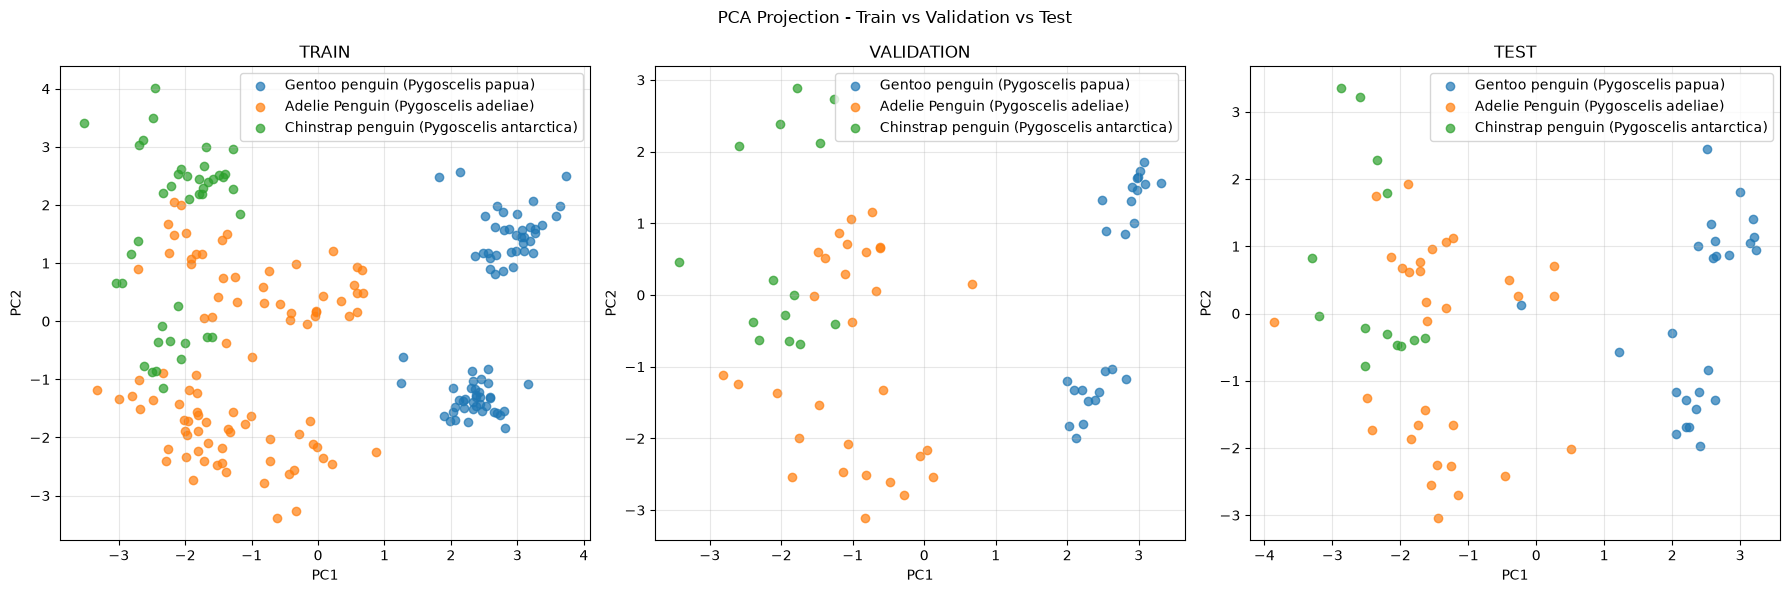

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

species_list = y_train.unique()

# TRAIN
for species in species_list:
    mask = (y_train == species).values

    axes[0].scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=species,
        alpha=0.7
    )

axes[0].set_title("TRAIN")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()
axes[0].grid(alpha=0.3)


# VALIDATION
for species in species_list:
    mask = (y_val == species).values

    axes[1].scatter(
        X_val_pca[mask, 0],
        X_val_pca[mask, 1],
        label=species,
        alpha=0.7
    )

axes[1].set_title("VALIDATION")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend()
axes[1].grid(alpha=0.3)


# TEST
for species in species_list:
    mask = (y_test == species).values

    axes[2].scatter(
        X_test_pca[mask, 0],
        X_test_pca[mask, 1],
        label=species,
        alpha=0.7
    )

axes[2].set_title("TEST")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("PCA Projection - Train vs Validation vs Test")
plt.tight_layout()
plt.show()

### Dumbed Down Version - What Does This PCA Graph Show?

Each dot is one penguin.

The colours show the species:

- Blue = Gentoo
- Orange = Adelie
- Green = Chinstrap

The 3 graphs show the same PCA transformation on:

**Train, Validation, and Test**

### What I Notice

Gentoo penguins form a pretty clear group on the right side of the graph.

Adelie and Chinstrap penguins overlap more on the left side.

The same general pattern appears in Train, Validation, and Test.

That is good because it means the PCA transformation is behaving consistently across all 3 datasets.

### Super Simple Version

PCA squished 16 features into 2 combo features so I could draw the penguins on a graph.

The graph still shows real structure:

**Gentoo looks pretty different.**

**Adelie and Chinstrap look more similar to each other.**

So even with only 2 principal components, PCA kept enough information to show useful patterns.

# Part 12 - Tune the Number of PCA Components

So far I have used rules like:

- how much variance is kept
- eigenvalues
- the scree plot

Now I want to test which number of PCA components actually works best for prediction.

I will try:

2, 3, 4, 5, 6, 8, and 10 components.

For each one:

1. PCA learns from Train
2. A simple classifier learns from Train
3. Validation checks how well it worked

### Dumbed Down Version

Basically:

"Try different amounts of PCA squishing and see which one still predicts penguin species best."

Train does the learning.

Validation helps choose the best setting.

Test is STILL left alone.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

results = []

for n in [2, 3, 4, 5, 6, 8, 10]:

    # PCA learns from TRAIN
    pca = PCA(n_components=n, random_state=42)

    X_train_pca_n = pca.fit_transform(X_train_scaled)
    X_val_pca_n = pca.transform(X_val_scaled)

    # Classifier learns from TRAIN
    clf = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    clf.fit(X_train_pca_n, y_train)

    # VALIDATION checks performance
    val_predictions = clf.predict(X_val_pca_n)
    val_accuracy = accuracy_score(y_val, val_predictions)

    results.append({
        "Components": n,
        "Validation Accuracy": val_accuracy
    })

results_df = pd.DataFrame(results)

results_df["Validation Accuracy (%)"] = (
    results_df["Validation Accuracy"] * 100
)

results_df[
    ["Components", "Validation Accuracy (%)"]
].round(2)

,Components,Validation Accuracy (%)
0,2,88.41
1,3,88.41
2,4,100.00
3,5,100.00
4,6,100.00
5,8,100.00
6,10,100.00


### Dumbed Down Version - What Did Validation Tell Me?

I tested several different amounts of PCA compression.

My results were:

- 2 components = 88.41% accuracy
- 3 components = 88.41% accuracy
- 4 components = 100% accuracy
- 5 components = 100% accuracy
- 6 components = 100% accuracy
- 8 components = 100% accuracy
- 10 components = 100% accuracy

Accuracy jumped to 100% when I reached 4 components.

Adding more components after 4 did not improve the validation accuracy.

So the code selected:

**4 PCA components**

### Why 4 instead of 5, 6, 8, or 10?

They all reached the same 100% validation accuracy.

Since 4 is the first and smallest option that reached the best score, it was selected.

**Same validation performance, fewer components.**

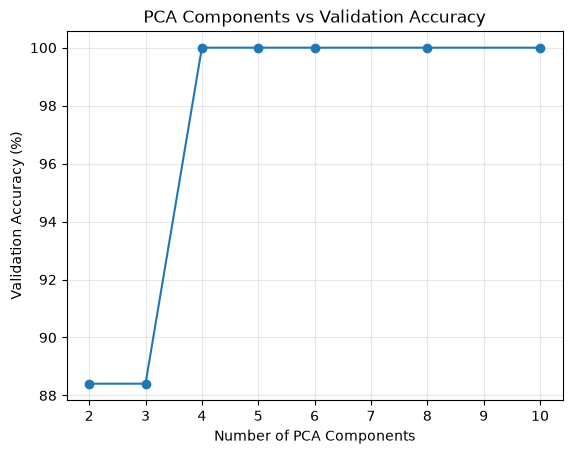

In [42]:
plt.plot(
    results_df["Components"],
    results_df["Validation Accuracy (%)"],
    marker="o"
)

plt.title("PCA Components vs Validation Accuracy")
plt.xlabel("Number of PCA Components")
plt.ylabel("Validation Accuracy (%)")
plt.grid(alpha=0.3)
plt.show()

### How to Read This Graph

The graph shows how validation accuracy changes when I keep different numbers of PCA components.

The big improvement happens between:

**3 components → 4 components**

After 4 components, the line becomes completely flat at 100%.

That means adding more PCA components did not improve validation performance in this experiment.

In [43]:
best_n = results_df.loc[
    results_df["Validation Accuracy"].idxmax(),
    "Components"
]

print("Best number of PCA components:", best_n)

Best number of PCA components: 4


# Part 13 - Final Evaluation on the Test Set

Validation selected the number of PCA components.

My selected value is:

**4 components**

Now I use that choice on the Test set.

The Test set has been kept separate until now.

### Dumbed Down Version

Train = study

Validation = practice test

Test = final exam

We already used the practice test to choose 4 components.

Now we take the final exam.

**Whatever score we get is the final result.**

We do NOT use the Test score to go back and change our settings.

In [44]:
# Final PCA using the number chosen by Validation
pca_final = PCA(
    n_components=best_n,
    random_state=42
)

# PCA learns from TRAIN only
X_train_final = pca_final.fit_transform(X_train_scaled)

# TEST uses the PCA learned from Train
X_test_final = pca_final.transform(X_test_scaled)

# Train final classifier
clf_final = LogisticRegression(
    max_iter=1000,
    random_state=42
)

clf_final.fit(X_train_final, y_train)

# Final TEST prediction
test_predictions = clf_final.predict(X_test_final)

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print("PCA components used:", best_n)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

PCA components used: 4
Final Test Accuracy: 97.10%


In [45]:
final_summary = pd.DataFrame({
    "Stage": [
        "Validation Best",
        "Final Test"
    ],
    "PCA Components": [
        best_n,
        best_n
    ],
    "Accuracy (%)": [
        results_df["Validation Accuracy"].max() * 100,
        test_accuracy * 100
    ]
})

final_summary.round(2)

,Stage,PCA Components,Accuracy (%)
0,Validation Best,4,100.0
1,Final Test,4,97.1


### Dumbed Down Version - Final Test Result

Validation told me that **4 PCA components** worked best.

Validation accuracy was:

**100%**

Then I used the untouched Test set for the final check.

Final Test accuracy was:

**97.10%**

That means the model correctly predicted the penguin species for about **97 out of every 100 test penguins**.

The Test score is slightly lower than Validation, which is normal.

The important thing is that the Test score is still very close to the Validation score.

### Final Rule

I do NOT go back and change the number of PCA components now.

The Test set was the final exam.

**Final result = 97.10% accuracy using 4 PCA components.**

# Part 14 - When Should I Use PCA?

PCA is useful when I want to reduce the number of features while keeping as much useful information as possible.

### PCA is useful for:

- reducing lots of columns into fewer columns
- visualizing high-dimensional data
- combining features that contain overlapping information
- speeding up some machine learning models

### PCA may NOT be the best choice when:

- I need to easily explain what every original feature means
- class separation is the main goal
- the data has strong non-linear patterns

### Dumbed Down Version

PCA is good when I have:

**too many columns + overlapping information**

and I want:

**fewer columns without losing too much information**

The downside is that the new PCs are combinations of the original features, so they are harder to explain individually.

# Part 15 - Export the PCA Data

Now I save the PCA results as CSV files.

I will save Train, Validation, and Test separately.

The exported files contain:

- PC1
- PC2
- species

### Dumbed Down Version

We did all the cleaning and PCA work.

Now we save the finished result so another machine learning model could use it later.

Basically:

**do the work → save the finished data**

In [46]:
import os

output_dir = "../Data"

# TRAIN
df_train_out = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"]
)

df_train_out["species"] = y_train.reset_index(drop=True).values

train_path = os.path.join(
    output_dir,
    "penguins_pca_train.csv"
)

df_train_out.to_csv(train_path, index=False)


# VALIDATION
df_val_out = pd.DataFrame(
    X_val_pca,
    columns=["PC1", "PC2"]
)

df_val_out["species"] = y_val.reset_index(drop=True).values

val_path = os.path.join(
    output_dir,
    "penguins_pca_validation.csv"
)

df_val_out.to_csv(val_path, index=False)


# TEST
df_test_out = pd.DataFrame(
    X_test_pca,
    columns=["PC1", "PC2"]
)

df_test_out["species"] = y_test.reset_index(drop=True).values

test_path = os.path.join(
    output_dir,
    "penguins_pca_test.csv"
)

df_test_out.to_csv(test_path, index=False)


print("Saved:")
print(train_path)
print(val_path)
print(test_path)

Saved:
../Data\penguins_pca_train.csv
../Data\penguins_pca_validation.csv
../Data\penguins_pca_test.csv


In [47]:
export_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Rows Saved": [
        len(df_train_out),
        len(df_val_out),
        len(df_test_out)
    ],
    "Columns Saved": [
        df_train_out.shape[1],
        df_val_out.shape[1],
        df_test_out.shape[1]
    ],
    "File": [
        "penguins_pca_train.csv",
        "penguins_pca_validation.csv",
        "penguins_pca_test.csv"
    ]
})

export_summary

,Dataset,Rows Saved,Columns Saved,File
0,Train,206,3,penguins_pca_train.csv
1,Validation,69,3,penguins_pca_validation.csv
2,Test,69,3,penguins_pca_test.csv


### Dumbed Down Version

For this export step, the activity saves the **2-component PCA version** of the data.

Each exported file contains:

- PC1
- PC2
- species

This is separate from the final tuned model above, which selected 4 PCA components.

# Part 16 - Common Mistakes / Final Notes

This section is mainly a reminder of the important rules used throughout the activity.

### Things to remember

- `species` is the target, so it should never be used as a PCA input feature.
- Split into Train / Validation / Test BEFORE learning preprocessing rules.
- Train is the only dataset allowed to learn:
  - missing-value medians
  - encoding categories
  - scaling values
  - PCA components
- Validation is used to choose settings.
- Test is used only once for the final evaluation.
- Standardize the features before PCA.
- More PCA components keep more information, but more is not always necessary.

### Dumbed Down Version

**Train learns.**

**Validation helps choose.**

**Test is the final exam.**

And PCA basically means:

**take lots of overlapping columns → combine them into fewer useful summary columns.**

# Activity Complete ✅

### Final Results

- Original dataset: **344 penguins**
- Original columns: **17**
- After removing useless ID/date/text columns: **12 columns**
- Features going into PCA after encoding: **16**
- Final PCA choice: **4 components**
- Best Validation Accuracy: **100%**
- Final Test Accuracy: **97.10%**

### What I Learned

The data was cleaned, split, encoded, standardized, and reduced using PCA.

Validation showed that 4 principal components were enough for the best validation performance.

The final model achieved **97.10% accuracy** on the untouched Test set.

The PCA data was also exported into separate Train, Validation, and Test CSV files.

## Possible Improvements / Next Steps

The final Test accuracy was **97.10%**, so the model already performed very well.

If this project were continued, some possible improvements could be:

- collect more penguin data
- collect more examples from the smaller Chinstrap class
- reduce missing measurements during data collection
- compare PCA with other feature-selection methods
- try other classifiers besides Logistic Regression
- use cross-validation during model development
- test whether different feature combinations improve performance

Because the Test set was already used for the final evaluation, I would **not** keep changing this model based on the 97.10% Test result.

Future improvements should be developed using Train/Validation data and then evaluated using a new untouched Test set.